# Processo seletivo CiS IEEE.

### imports:


In [31]:
import csv
import pandas as pd
import numpy as np
from scipy.stats import mstats as sts
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import accuracy_score as AS
from sklearn.metrics import roc_curve, auc
import seaborn as sns

## Questão 1
Existem valores faltantes ou outliers no dataset? Se sim, como você abordaria o
tratamento dessas inconsistências? Explique as técnicas que utilizaria para lidar
com essas questões

Sim, ambos existem no data set, trabalharei neles agora

### Identificações iniciais

Primeiro análise de dados faltantes.

In [9]:
with open('diabetes.csv', 'r') as file:
  leitor = csv.reader(file)
  cabeçalho = next(leitor)
  i=0
  for linha in leitor:
    for item in linha:
      if item == '':
        i+=1
  print(i)

49


Localizar dados faltantes:

In [10]:
with open('diabetes.csv', 'r') as file:
  leitor = csv.reader(file)
  cabeçalho = next(leitor)
  i=0
  for i, linha in enumerate(leitor):
    for j, item in enumerate(linha):
      if item == '':
        print(f"Linha {i+1}, Coluna {j+1}: Dado faltante")
        print(f"Dado Faltante: {cabeçalho[j]}\n")

Linha 17, Coluna 6: Dado faltante
Dado Faltante: BMI

Linha 19, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 25, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 51, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 51, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 74, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 98, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 129, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 285, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 287, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 291, Coluna 7: Dado faltante
Dado Faltante: DiabetesPedigreeFunction

Linha 321, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 324, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 612, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 613, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 614, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 61

Traduzir em panda

In [11]:
# ds=Data Set
ds = pd.read_csv('diabetes.csv')

# ms = missing data

ms=ds.isna()

for i in range(len(ds)):
    for j, col in enumerate(ds.columns):
      if ms.iloc[i, j]:
        print(f"Linha {i+1}, Coluna {j+1}: Dado faltante")
        print(f"Dado Faltante: {col}\n")

Linha 17, Coluna 6: Dado faltante
Dado Faltante: BMI

Linha 19, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 25, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 51, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 51, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 74, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 98, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 129, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 285, Coluna 4: Dado faltante
Dado Faltante: SkinThickness

Linha 287, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 291, Coluna 7: Dado faltante
Dado Faltante: DiabetesPedigreeFunction

Linha 321, Coluna 5: Dado faltante
Dado Faltante: Insulin

Linha 324, Coluna 2: Dado faltante
Dado Faltante: Glucose

Linha 612, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 613, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 614, Coluna 3: Dado faltante
Dado Faltante: BloodPressure

Linha 61

estudo de dado outlier:

"Em estatística, outlier, valor aberrante ou valor atípico, é uma observação que apresenta um grande afastamento das demais da série, ou que é inconsistente. A existência de outliers implica, tipicamente, em prejuízos à interpretação dos resultados dos testes estatísticos aplicados às amostras."

In [12]:
# cn = coluna numérica
cn = ds.select_dtypes(include=['int64', 'float64']).columns

for coluna in cn:
  q1 = ds[coluna].quantile(0.25)
  q3 = ds[coluna].quantile(0.75)
  qr = q3-q1

  # ls = limite superior; li = limite inferior
  li = q1 - 1.5*qr
  ls = q3 + 1.5*qr

  # LcO = Localização de Outliers.
  # LcO indentifica se o item dela está maior ou menor que o 'permitido' em ls ou li
  LcO = ds[((ds[coluna]<li) | (ds[coluna]>ls))]

  print(f"\nOutliers em {coluna}: {len(LcO)}")
  print(LcO[[coluna]])


Outliers em Pregnancies: 4
     Pregnancies
88            15
159           17
298           14
455           14

Outliers em Glucose: 5
     Glucose
75       0.0
182      0.0
342      0.0
349      0.0
502      0.0

Outliers em BloodPressure: 44
     BloodPressure
7              0.0
15             0.0
18            30.0
43           110.0
49             0.0
60             0.0
78             0.0
81             0.0
84           108.0
106          122.0
125           30.0
172            0.0
177          110.0
193            0.0
222            0.0
261            0.0
266            0.0
269            0.0
300            0.0
332            0.0
336            0.0
347            0.0
357            0.0
362          108.0
426            0.0
430            0.0
435            0.0
453            0.0
468            0.0
484            0.0
494            0.0
522            0.0
533            0.0
535            0.0
549          110.0
589            0.0
597           24.0
601            0.0
604          

Tratamento de Outliers:
1. Irei fazer uma remoção de outliers e farei o cálculo sem eles
2. depois farei uma transformação para 'ajeitar' os outliers e aí sim fazer o cálculo com eles mais uma vez para fazer uma comparação.


Tratamento de falta de Info:
1. Não utilizarei as partes faltantes, pois, contrário do outlier, dados faltantes podem ser tanto 0 quanto $\infty$.

### Remoção de Outliers


In [13]:
def remocao_de_outliers(ds, colunas):
  ds_limpo = ds.copy()
  for coluna in colunas:
    q1 = ds[coluna].quantile(0.25)
    q3 = ds[coluna].quantile(0.75)
    qr = q3-q1

  # ls = limite superior; li = limite inferior
    li = q1 - 1.5*qr
    ls = q3 + 1.5*qr

  # remove todos os outliers
    ds_limpo = ds_limpo[(ds_limpo[coluna]>=li) & (ds_limpo[coluna]<=ls)]
  return ds_limpo

colunas_num = ds.select_dtypes(include=['int64', 'float64']).columns.drop('Outcome')
ds_sem_out = remocao_de_outliers(ds, colunas_num)

x = ds_sem_out.drop('Outcome', axis=1)
y = ds_sem_out['Outcome']

#utiliza uma rede neural para descobrir se tem ou nao uma diabete de forma mais precisa.
modelo = LR(max_iter=1000)
modelo.fit(x, y)
preds = modelo.predict(x)

print(f"Acurácia SEM outliers: {AS(y, preds)}")
print("\nExemplo das primeiras 10 classificações:")
print(pd.DataFrame({
    'Real': y.head(10),
    'Predito': preds[:10]
}))

Acurácia SEM outliers: 0.7926421404682275

Exemplo das primeiras 10 classificações:
    Real  Predito
0      1        1
1      0        0
2      1        1
3      0        0
5      0        0
6      1        0
10     0        0
11     1        1
14     1        1
17     1        0


### Tratamento de Outliers

In [14]:
ds_tratado = ds.copy()
colunas_numericas = ds.select_dtypes(include=['int64', 'float64']).columns.drop('Outcome')
for coluna in colunas_numericas:
    ds[coluna] = sts.winsorize(ds[coluna], limits=[0.05, 0.05])

# Preparar dados
X = ds.drop('Outcome', axis=1)
y = ds['Outcome']

# Treinar modelo
modelo = LR(max_iter=1000)
modelo.fit(X, y)

ds['Predicao_Diabetes'] = modelo.predict(X)

print(ds[['Outcome', 'Predicao_Diabetes']].head(20))

    Outcome  Predicao_Diabetes
0         1                  1
1         0                  0
2         1                  1
3         0                  0
4         1                  1
5         0                  0
6         1                  0
7         0                  0
8         1                  1
9         1                  0
10        0                  0
11        1                  1
12        0                  1
13        1                  1
14        1                  1
15        1                  0
16        1                  0
17        1                  0
18        0                  0
19        1                  0


## Questão 2:
Como as principais variáveis (Glucose, BloodPressure, BMI, etc.) estão
distribuídas? Utilize histogramas e boxplots para representar visualmente essas
distribuições e analise as características de cada uma.


### Boxplots:

imports

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

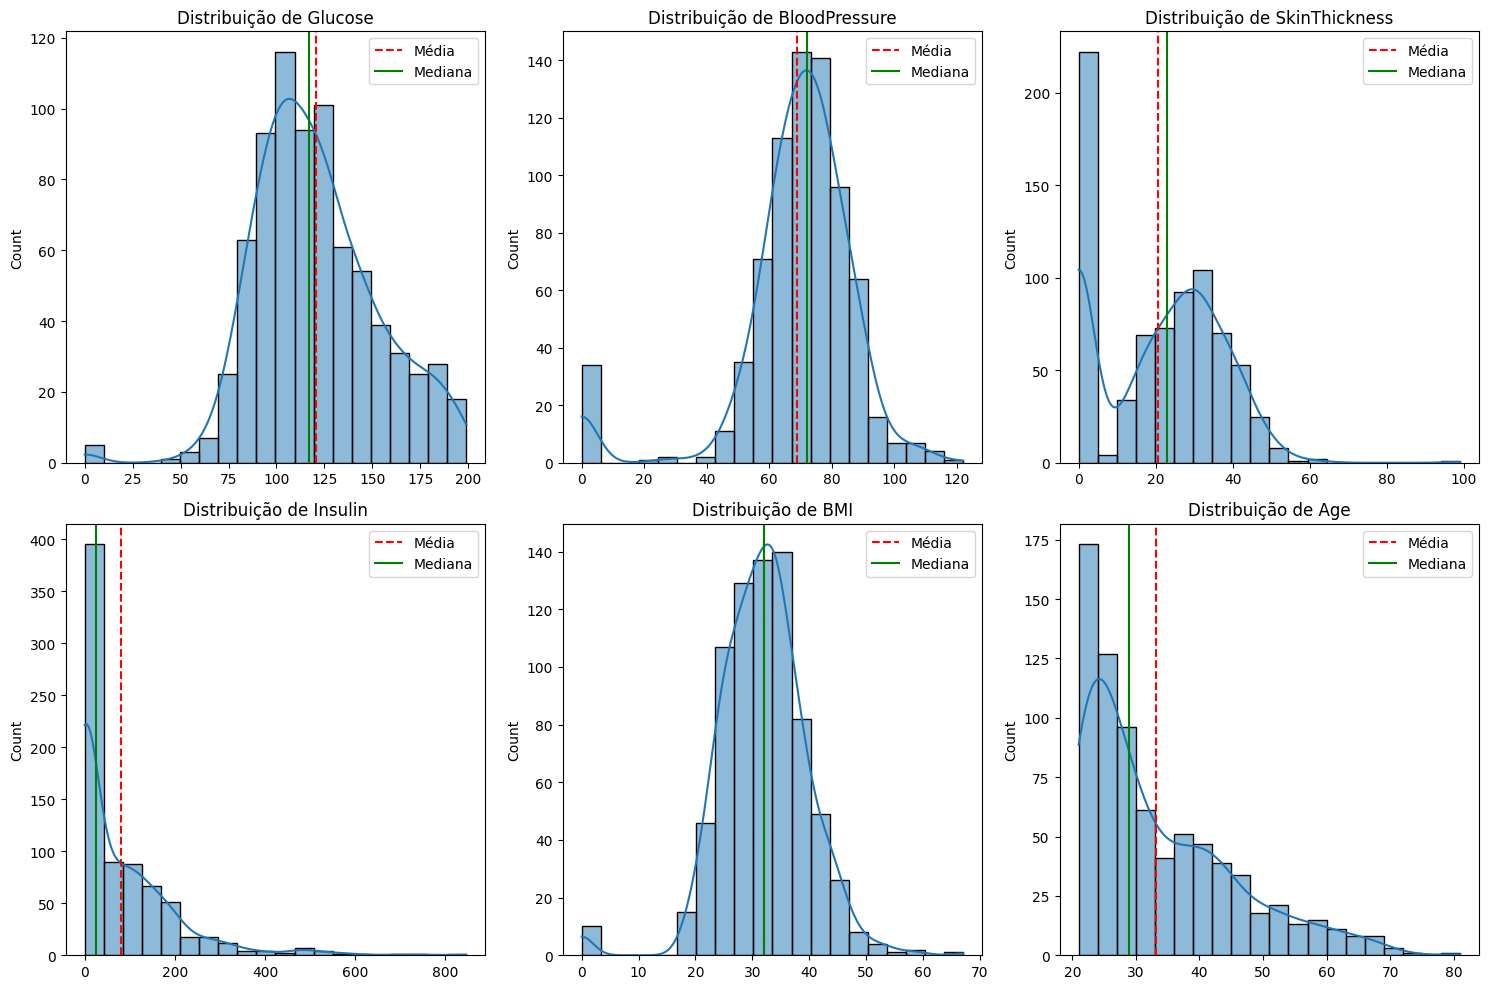

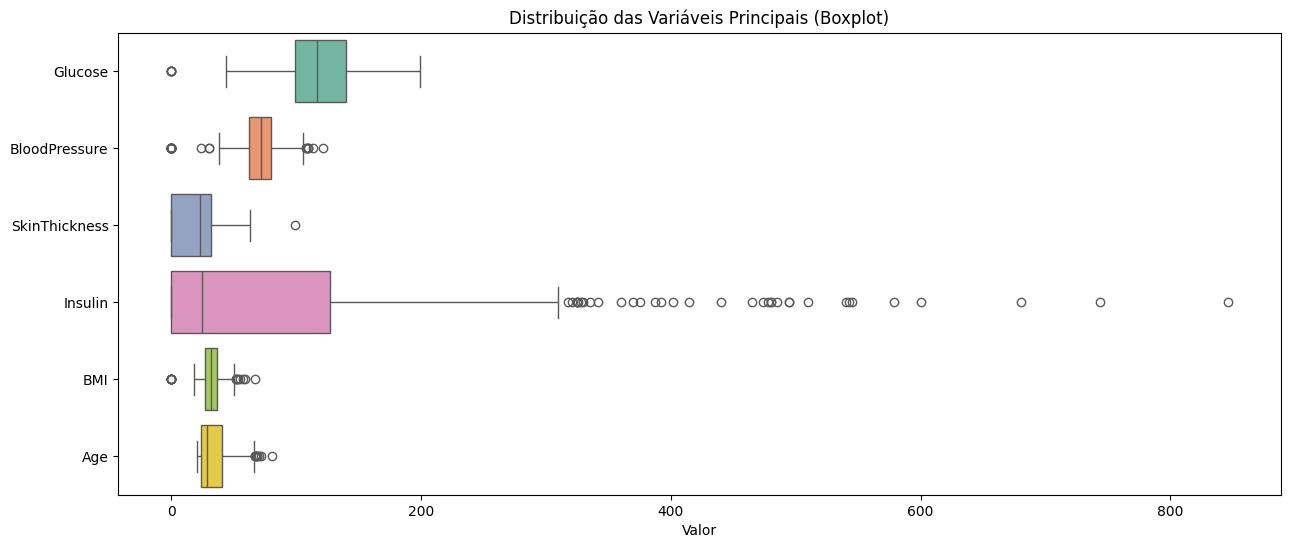

In [16]:
ds = pd.read_csv('diabetes.csv')

# Selecionar as principais variáveis
variaveis = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

# Configuração dos gráficos
plt.figure(figsize=(15, 10))

# Histogramas
for i, var in enumerate(variaveis, 1):
    plt.subplot(2, 3, i)
    sns.histplot(ds[var], kde=True, bins=20)
    plt.title(f'Distribuição de {var}')
    plt.xlabel('')
    plt.axvline(ds[var].mean(), color='r', linestyle='--', label='Média')
    plt.axvline(ds[var].median(), color='g', linestyle='-', label='Mediana')
    plt.legend()

plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(15, 6))
sns.boxplot(data=ds[variaveis], orient='h', palette='Set2')
plt.title('Distribuição das Variáveis Principais (Boxplot)')
plt.xlabel('Valor')
plt.show()

### Análise:

1. Glucose:
 - Distribuida em picos com ~100ml sendo normal e ~140ml sendo alterado.
 - Assimétrico à direita.
2. Blood Pressure:
 - assimétrica à esquerda.
 - diversos dados faltantes, tendo um pico em 0.
3. skin thickness:
 - assimétrica à esquerda.
 - pico em 0.
4. insulin:
 - MUITO assimétrica.
 - grande concentração em 0.
5. BMI:
 - bem distríbuida, com assimetria fútil à direita.
6. Age:
 - assimétrica à direita.
 - pico em 20.


## Questão 3:
Existe uma correlação entre a idade dos indivíduos e a presença de diabetes?
Realize uma análise estatística (como teste de correlação) e utilize gráficos (como
scatter plot ou boxplot) para ilustrar essa relação.


### Boxplot

/usr/local/lib/python3.11/dist-packages/numpy/ma/core.py:5384: RuntimeWarning: Mean of empty slice.
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
<ipython-input-26-3dbbb4877332>:4: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print(f"Valor-p: {p_value:.4f}")
<ipython-input-26-3dbbb4877332>:24: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  plt.annotate(f'Correlação: {corr:.2f}\nValor-p: {p_value:.4f}',


Correlação Idade-Diabetes: nan
Valor-p: --

Não há evidências de correlação significativa


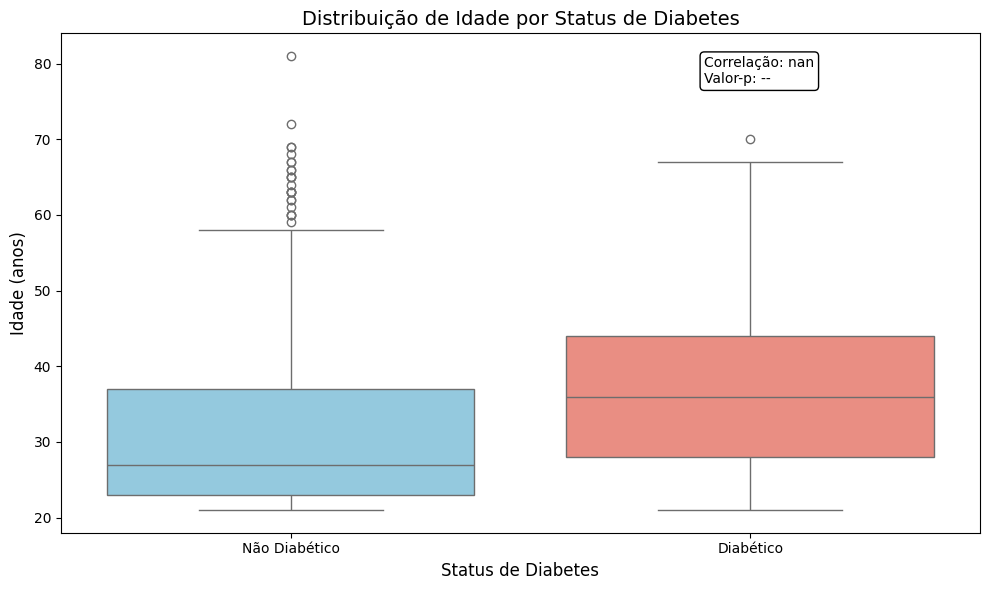

In [26]:
corr, p_value = sts.pointbiserialr(ds['Age'], ds['Outcome'])

print(f"Correlação Idade-Diabetes: {corr:.3f}")
print(f"Valor-p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nHá evidências estatísticas de correlação significativa (p < 0.05)")
else:
    print("\nNão há evidências de correlação significativa")

plt.figure(figsize=(10, 6))

sns.boxplot(x='Outcome', y='Age', data=ds,
            hue='Outcome', palette=['skyblue', 'salmon'],
            dodge=False, legend=False)

plt.title('Distribuição de Idade por Status de Diabetes', fontsize=14)
plt.xlabel('Status de Diabetes', fontsize=12)
plt.ylabel('Idade (anos)', fontsize=12)
plt.xticks([0, 1], ['Não Diabético', 'Diabético'])


plt.annotate(f'Correlação: {corr:.2f}\nValor-p: {p_value:.4f}',
             xy=(0.7, 0.9), xycoords='axes fraction',
             bbox=dict(boxstyle='round', fc='white'))

plt.tight_layout()
plt.show()

### Análise:

- a diferença não é significativa, contúdo é aparente que pessoas com ~35 anos têm uma tendencia maior de ter diabetes dentro deste Data Set e pessoas com ~28 anos tendem a não ter, porém a diferença não é grande o suficiente para ditar uma "correlação".

## Questao 4:
Quais variáveis apresentam maior correlação com a presença de diabetes? Quais
variáveis parecem ser as mais indicativas da presença de diabetes?


### Boxplots:

<ipython-input-27-61533b413fa0>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacoes.values, y=correlacoes.index, palette='coolwarm')


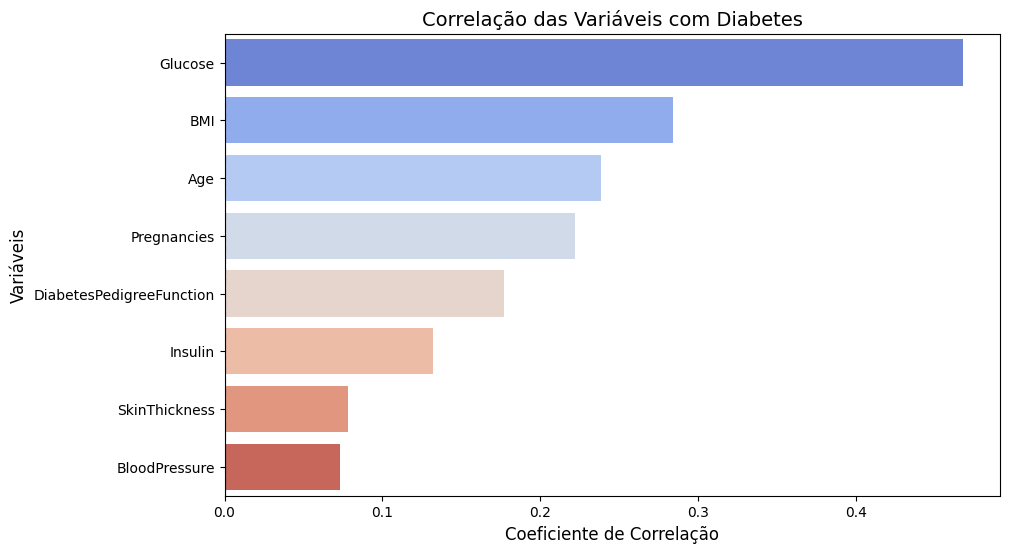

In [27]:
correlacoes = ds.corr()['Outcome'].sort_values(ascending=False)[1:] # .corr()['outcome'] faz uma correlação automáticamente com todas as outras áreas do csv, .sort_values ajeita eles de forma correta, [1:] tira a barra 'outcome'

plt.figure(figsize=(10, 6))
sns.barplot(x=correlacoes.values, y=correlacoes.index, palette='coolwarm')
plt.title('Correlação das Variáveis com Diabetes', fontsize=14)
plt.xlabel('Coeficiente de Correlação', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.axvline(0, color='black', linestyle='--')
plt.show()

### Análise:
- Como esperado, a glucose tem uma correlação com a diabete gritante quando comparada às outras variáveis, as mais indicativas tendem a ser BMI e Glucose.

## Questão 5:
Existe uma relação entre o IMC dos pacientes e o diagnóstico de diabetes?
Compare os valores médios de IMC entre os grupos com e sem diabetes, e
analise a diferença estatisticamente.


### Boxplot:

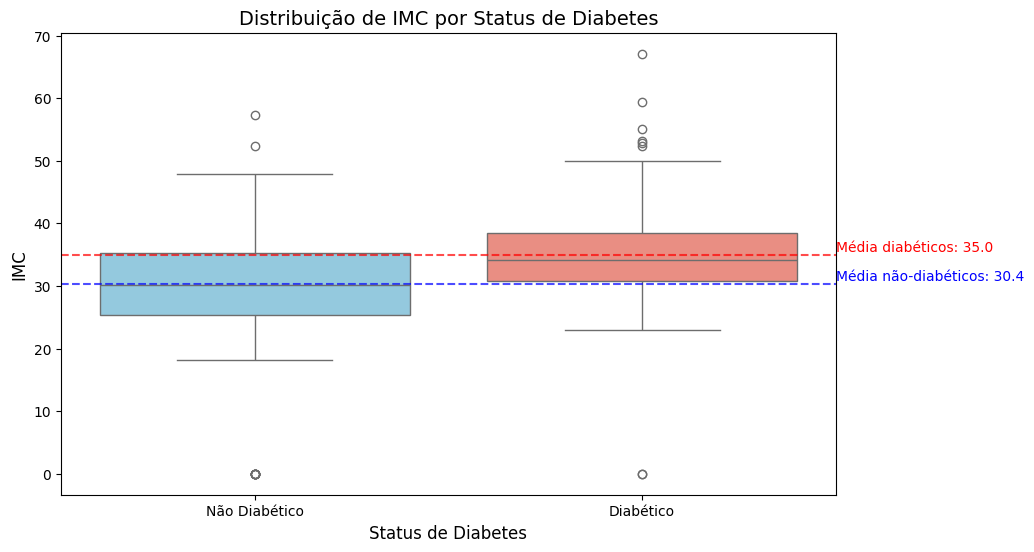

In [29]:
bmi_diabeticos = ds[ds['Outcome'] == 1]['BMI']
bmi_nao_diabeticos = ds[ds['Outcome'] == 0]['BMI']


plt.figure(figsize=(10, 6))

sns.boxplot(x='Outcome', y='BMI', data=ds,
            hue='Outcome', palette={0:'skyblue', 1:'salmon'},
            dodge=False, legend=False)
plt.title('Distribuição de IMC por Status de Diabetes', fontsize=14)
plt.xlabel('Status de Diabetes', fontsize=12)
plt.ylabel('IMC', fontsize=12)
plt.xticks([0, 1], ['Não Diabético', 'Diabético'])

plt.axhline(bmi_nao_diabeticos.mean(), color='blue', linestyle='--', alpha=0.7)
plt.axhline(bmi_diabeticos.mean(), color='red', linestyle='--', alpha=0.7)
plt.text(1.5, bmi_nao_diabeticos.mean()+0.5, f'Média não-diabéticos: {bmi_nao_diabeticos.mean():.1f}', color='blue')
plt.text(1.5, bmi_diabeticos.mean()+0.5, f'Média diabéticos: {bmi_diabeticos.mean():.1f}', color='red')

plt.show()

### Análise:
- É aparente que pessoas com um imc pior tendem a ter mais casos de diabetes, é possível inferir isso com este boxplot e com o anterior.

## Questão 6:
Existe um valor específico de glicose que pode ser considerado crítico para o
diagnóstico de diabetes? Utilize gráficos de dispersão e cálculos estatísticos para
investigar esse ponto e definir um limite crítico, se possível.

### Boxplot:

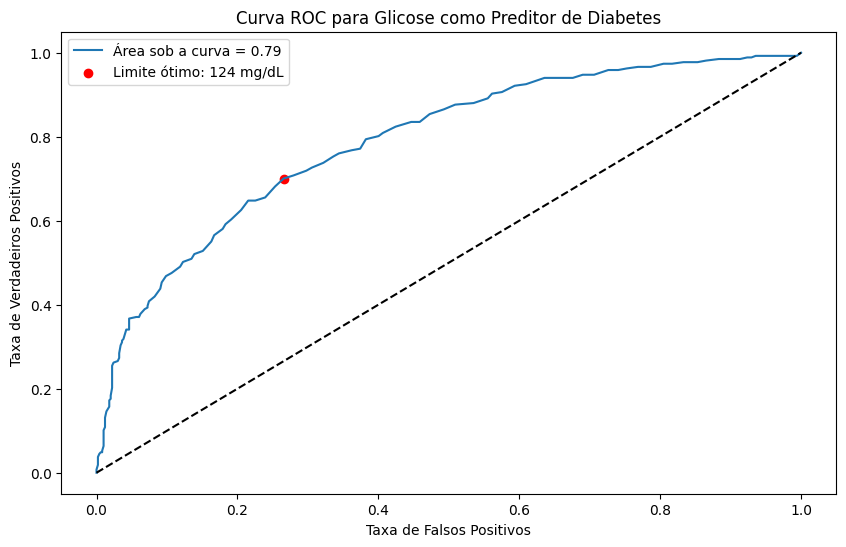

In [38]:
ds_clean = ds.dropna(subset=['Glucose','Outcome'])
if len(ds_clean) > 10:
    fpr, tpr, thresholds = roc_curve(ds_clean['Outcome'], ds_clean['Glucose'])
    roc_auc = auc(fpr, tpr)

    # Encontrar o ponto ótimo (Índice de Youden)
    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]

    # Plotar
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'Área sob a curva = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red',
                label=f'Limite ótimo: {optimal_threshold:.0f} mg/dL')
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title('Curva ROC para Glicose como Preditor de Diabetes')
    plt.legend()
    plt.show()

O ponto crítico para ter diabetes é em 124mg/dl

## Questão 7:
Treine um modelo de árvore de decisão para prever a presença de diabetes com
base nas variáveis do dataset. Qual foi a acurácia obtida? Discuta os resultados e
possíveis melhorias para o modelo.


### Resposta:
- Esta foi a metodologia utilizada para realizar a Questão 1, sua acurácia foi de 79,26%.
- Eu poderia utilizar um pré-processamento melhorado para fazer a questão, contudo ~80% é o suficiente para a questão.

## Questão 8:
A variável DiabetesPedigreeFunction está relacionada à presença de diabetes?
Pacientes com histórico familiar de diabetes apresentam maior risco? Realize
uma análise exploratória e estatística para verificar essa relação.

<ipython-input-41-71b1ea44769b>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=ds,


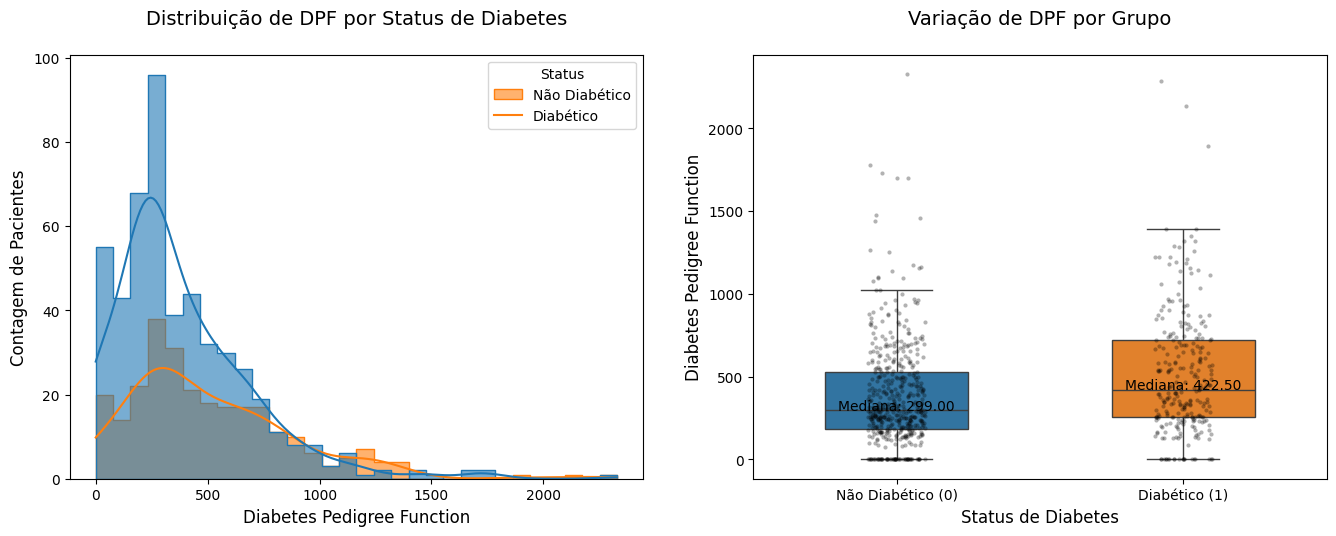

In [41]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=ds, x='DiabetesPedigreeFunction', hue='Outcome',
             bins=30, kde=True, element='step',
             palette={0:'#1f77b4', 1:'#ff7f0e'},
             alpha=0.6)
plt.title('Distribuição de DPF por Status de Diabetes\n', fontsize=14)
plt.xlabel('Diabetes Pedigree Function', fontsize=12)
plt.ylabel('Contagem de Pacientes', fontsize=12)
plt.legend(['Não Diabético', 'Diabético'], title='Status')

plt.subplot(1, 2, 2)
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=ds,
            palette={'#1f77b4', '#ff7f0e'},
            width=0.5, showfliers=False)
sns.stripplot(x='Outcome', y='DiabetesPedigreeFunction', data=ds,
              color='black', alpha=0.3, size=3)
plt.title('Variação de DPF por Grupo\n', fontsize=14)
plt.xlabel('Status de Diabetes', fontsize=12)
plt.ylabel('Diabetes Pedigree Function', fontsize=12)
plt.xticks([0, 1], ['Não Diabético (0)', 'Diabético (1)'])

medians = ds.groupby('Outcome')['DiabetesPedigreeFunction'].median()
for xtick in [0, 1]:
    plt.text(xtick, medians[xtick]+0.1, f'Mediana: {medians[xtick]:.2f}',
             horizontalalignment='center', fontsize=10)

plt.tight_layout(pad=3.0)
plt.show()

Sim, ela está ligada.

## Questão 9
Pacientes com mais de 50 anos têm taxas de diabetes mais altas do que
pacientes mais jovens? Utilize estatísticas descritivas e gráficos comparativos
para demonstrar as diferenças entre esses dois grupos etários.


Prevalência de Diabetes por Faixa Etária:
               mean  count
Faixa_Etaria              
≤50 anos      0.335    687
>50 anos      0.469     81

Diferença Absoluta:
13.43%


<ipython-input-43-7ba19b8a06fc>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(ds.groupby('Faixa_Etaria')['Outcome'].agg(['mean', 'count']).round(3))
<ipython-input-43-7ba19b8a06fc>:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Faixa_Etaria', y='Outcome', data=ds,
<ipython-input-43-7ba19b8a06fc>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Faixa_Etaria', y='Outcome', data=ds,


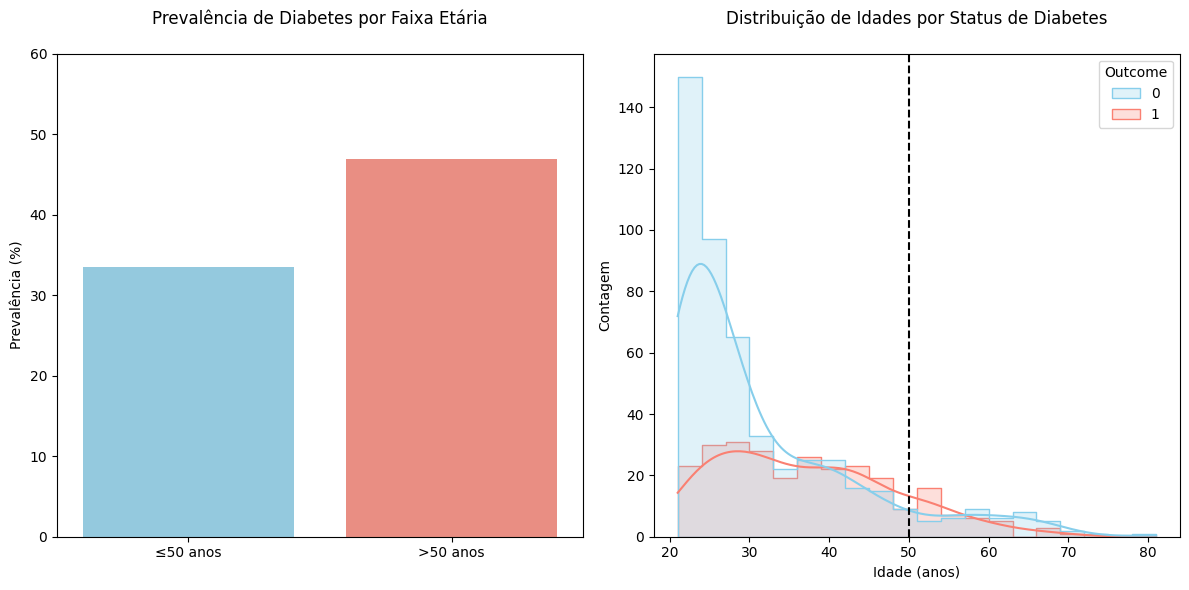

In [43]:
ds['Faixa_Etaria'] = pd.cut(ds['Age'],
                           bins=[20, 50, 100],
                           labels=['≤50 anos', '>50 anos'])


diabetes_maiores50 = ds[ds['Faixa_Etaria'] == '>50 anos']['Outcome']
diabetes_menores50 = ds[ds['Faixa_Etaria'] == '≤50 anos']['Outcome']
print("\nPrevalência de Diabetes por Faixa Etária:")
print(ds.groupby('Faixa_Etaria')['Outcome'].agg(['mean', 'count']).round(3))

print("\nDiferença Absoluta:")
print(f"{diabetes_maiores50.mean() - diabetes_menores50.mean():.2%}")

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
sns.barplot(x='Faixa_Etaria', y='Outcome', data=ds,
            estimator=lambda x: sum(x)/len(x)*100,
            ci=None, palette=['skyblue', 'salmon'])
plt.title('Prevalência de Diabetes por Faixa Etária\n')
plt.ylabel('Prevalência (%)')
plt.xlabel('')
plt.ylim(0, 60)

# Gráfico 2: Distribuição de Idades
plt.subplot(1, 2, 2)
sns.histplot(data=ds, x='Age', hue='Outcome',
             bins=20, kde=True,
             palette={0:'skyblue', 1:'salmon'},
             element='step')
plt.axvline(50, color='black', linestyle='--')
plt.title('Distribuição de Idades por Status de Diabetes\n')
plt.xlabel('Idade (anos)')
plt.ylabel('Contagem')

plt.tight_layout()
plt.show()

Eles têm uma taxa de diabetes _Menor_ que as pessoas com menos de 50 anos.

## Questão 10:
Utilize regressão logística para estimar a probabilidade de um paciente ser
diagnosticado com diabetes. Quais variáveis são mais influentes no modelo e
como elas impactam a probabilidade de diagnóstico?


Mais uma vez, este já foi o sistema empregado na questão 1, as variáveis mais influentes foram: Glucose, BMI e Pregnancies.

## Questão 11:
Quais técnicas de feature engineering podem ser aplicadas para melhorar a
previsão do diagnóstico de diabetes utilizando modelos de aprendizado de
máquina? Experimente transformar variáveis existentes, criar novas variáveis a
partir de combinações ou interações e utilize técnicas como encoding,
normalização ou transformação de características. Avalie o impacto dessas
mudanças no desempenho de um modelo de aprendizado de máquina (por
exemplo, Random Forest ou XGBoost).


pré-processamento seria ótimo para dar um Up na performance geral do programa, mas não se mostra muito necessário tendo em vista que o programa já é relativamente leve.
Features novas poderiam ser tão simples quanto "descrições" das variáveis atuais, como "abaixo", "média" e "acima" para o BMI.
Análise de Importância de Features com XGBoost seria ótimo para filtrar fácilmente o Data Set.